# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("loan_data.csv")

df['loan_status'] = df['loan_status'].astype(int)

loan_data = df.copy()
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


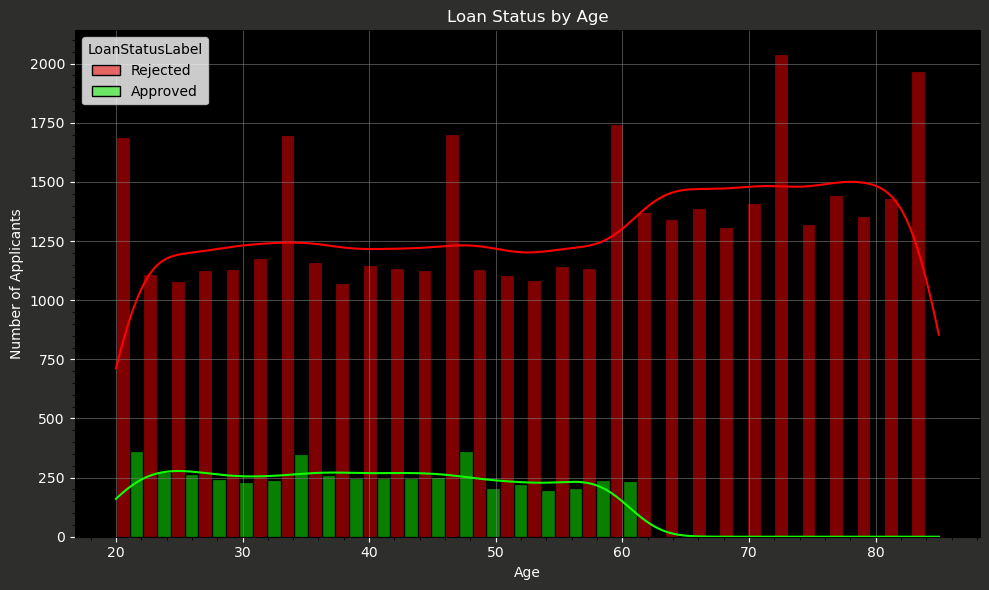

In [ ]:

loan_data['LoanStatusLabel'] = loan_data['loan_status'].map({0: "Rejected", 1: "Approved"})


age_data = loan_data[['person_age', 'LoanStatusLabel']].dropna()


fig_bg = '#2e2e2d'
ax_bg = 'black'
palette = {"Rejected": "#ff0000", "Approved": "#11ff00"}


fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data=age_data, x='person_age', hue='LoanStatusLabel', bins=30, kde=True,edgecolor='black', multiple="dodge", palette=palette)


fig.set_facecolor(fig_bg)
ax.set_facecolor(ax_bg)
ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.grid(True, axis='x', linestyle='-', linewidth=.4, color='gray')
ax.minorticks_on()
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.set_title("Loan Status by Age", color='white')
ax.set_xlabel("Age", color='white')
ax.set_ylabel("Number of Applicants", color='white')

plt.tight_layout()
plt.show()




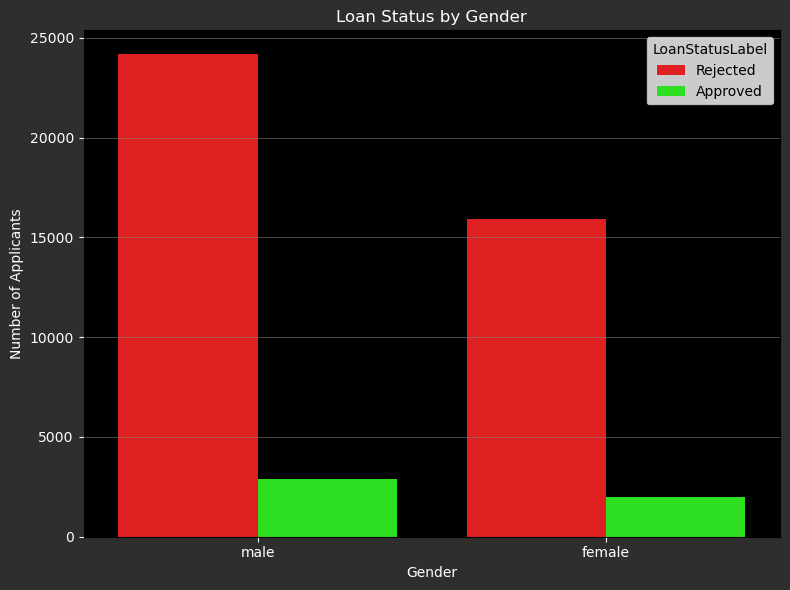

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

df['LoanStatusLabel'] = df['loan_status'].map({0: "Rejected", 1: "Approved"})


sns.countplot(
    data=df,
    x='person_gender',
    hue='LoanStatusLabel',
    palette={"Rejected": "#ff0000", "Approved": "#11ff00"}
)

fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')
ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Loan Status by Gender", color='white')
ax.set_xlabel("Gender", color='white')
ax.set_ylabel("Number of Applicants", color='white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()


C:\Users\heman\AppData\Local\Temp\ipykernel_116876\165808143.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


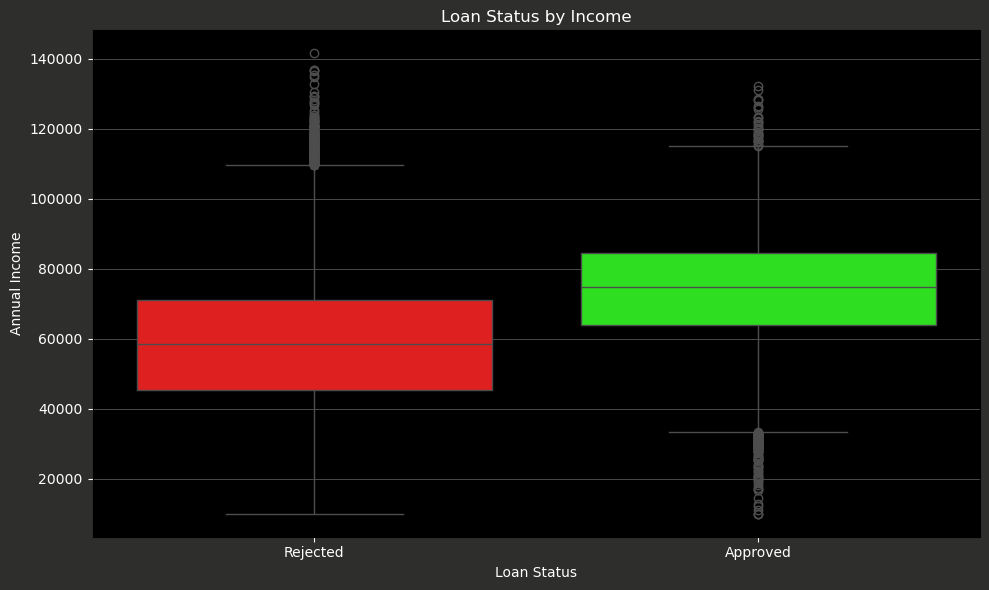

In [79]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='LoanStatusLabel',
    y='person_income',
    palette={"Rejected": "#ff0000", "Approved": "#11ff00"}
)

fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')
ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Loan Status by Income", color='white')
ax.set_xlabel("Loan Status", color='white')
ax.set_ylabel("Annual Income", color='white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()


C:\Users\heman\AppData\Local\Temp\ipykernel_116876\779625295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


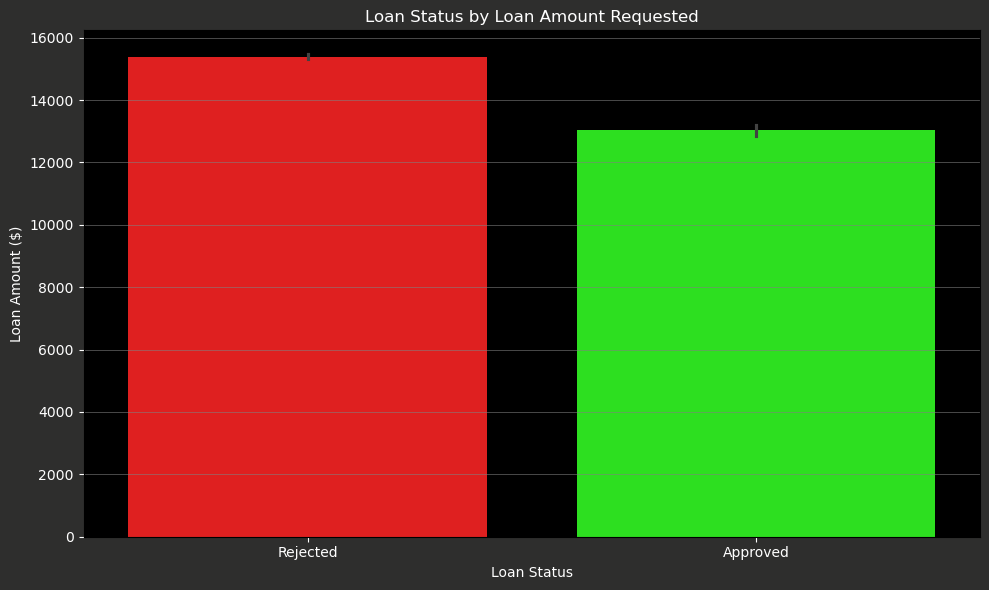

In [80]:
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=df,
    x='LoanStatusLabel',
    y='loan_amnt',
    palette={"Rejected": "#ff0000", "Approved": "#11ff00"},
    ax=ax
)

fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')
ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Loan Status by Loan Amount Requested", color='white')
ax.set_xlabel("Loan Status", color='white')
ax.set_ylabel("Loan Amount ($)", color='white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()




C:\Users\heman\AppData\Local\Temp\ipykernel_116876\398276179.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


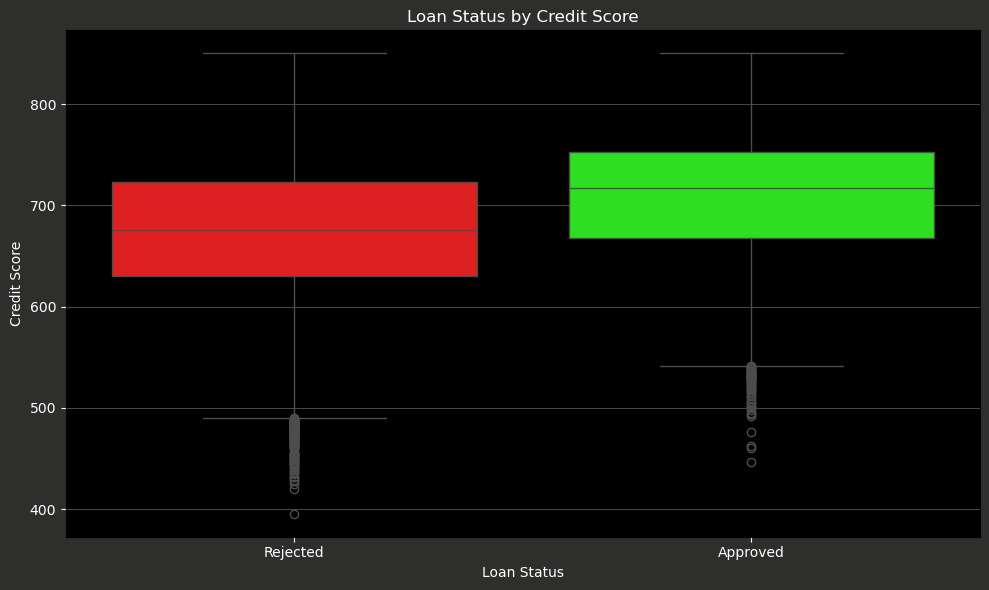

In [81]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=df,
    x='LoanStatusLabel',
    y='credit_score',
    palette={"Rejected": "#ff0000", "Approved": "#11ff00"}
)

fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')
ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Loan Status by Credit Score", color='white')
ax.set_xlabel("Loan Status", color='white')
ax.set_ylabel("Credit Score", color='white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()


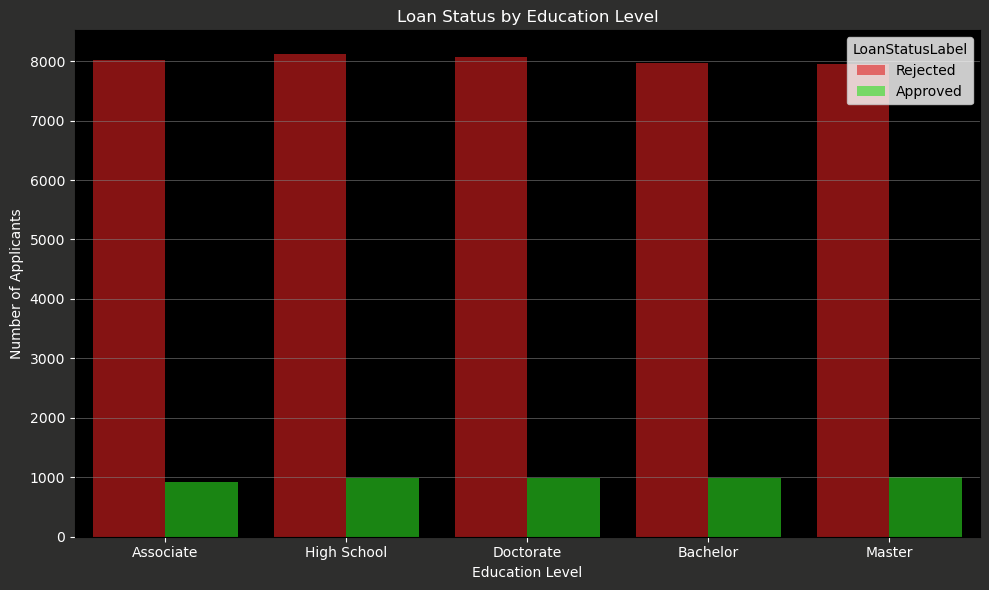

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

sns.countplot(
    data=df,
    x='person_education',
    hue='LoanStatusLabel',
    alpha = 0.6,
    palette={"Rejected": "#ff0000", "Approved": "#11ff00"}
)


fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')
ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Loan Status by Education Level", color='white')
ax.set_xlabel("Education Level", color='white')
ax.set_ylabel("Number of Applicants", color='white')
ax.tick_params(axis='x', colors='white', rotation=0)
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()


C:\Users\heman\AppData\Local\Temp\ipykernel_116876\589903230.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


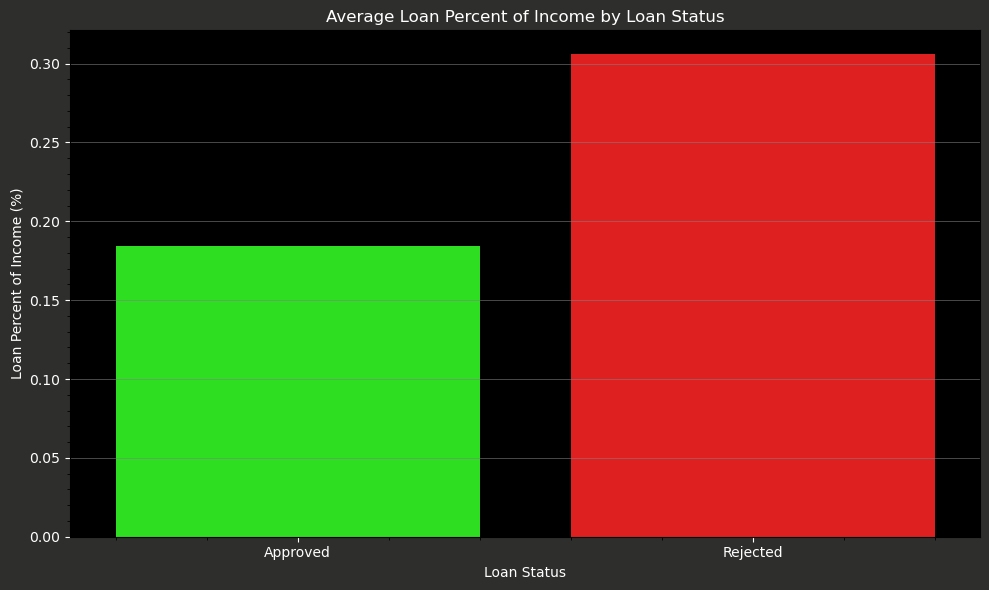

In [ ]:

avg_percent_income = df.groupby('LoanStatusLabel')['loan_percent_income'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    data=avg_percent_income,
    x='LoanStatusLabel',
    y='loan_percent_income',
    palette={"Rejected": "#ff0000", "Approved": "#11ff00"},
    ax=ax
)


fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')
ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.minorticks_on()
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.set_title("Average Loan Percent of Income by Loan Status", color='white')
ax.set_xlabel("Loan Status", color='white')
ax.set_ylabel("Loan Percent of Income (%)", color='white')

plt.tight_layout()
plt.show()


Age: Slightly affects approval; middle-aged applicants are approved more.

Gender: Could be a concern if one gender is favored; may indicate bias.

Income: Higher income increases approval; a valid factor.

Loan Amount: Smaller or moderate loans are approved more; a valid factor.

Credit Score: Higher scores strongly increase approval; a valid factor.

Education: Higher education slightly increases approval; minor factor.

Loan Percent of Income: Lower percentages are approved more; a valid factor.

Conclusion:
The model mainly uses income, loan amount, credit score, and loan percent of income to decide approvals. Gender and age could pose legal risks if they influence decisions unfairly.
